# 05 · Decision tree, random forest & feature importance

Tuned CART and a Random Forest, and the **permutation feature importance** that overturns the original study's headline.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import punching_shear as ps
REPO = Path(ps.__file__).resolve().parent.parent
RESULTS = REPO / 'results'
ds = ps.load_dataset()
print(f'{len(ds)} tests, {ds.groups.nunique()} researchers, features={ds.feature_names}')

336 tests, 55 researchers, features=['d', 'col_area', 'rho_l', 'fcm_cyl', 'u0_perim']


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
models = ps.build_models()
tree = ['Decision Tree','Random Forest']
Xtr,Xte,ytr,yte = train_test_split(ds.X, ds.y_stress, test_size=.3, random_state=19)
out=[]
for name in tree:
    gs=clone(models[name]).fit(Xtr,ytr)
    m=ps.regression_metrics(yte, gs.predict(Xte)); m['model']=name; m['best']=gs.best_params_; out.append(m)
display(pd.DataFrame(out)[['model','rmse','r2','mape_pct','best']])

,model,rmse,r2,mape_pct,best
0,Decision Tree,0.352267,0.450572,16.510953,"{'m__ccp_alpha': 0.0, 'm__max_depth': None, 'm..."
1,Random Forest,0.252308,0.718143,11.910829,"{'m__max_depth': None, 'm__max_features': 1.0,..."


### Permutation importance on the STRESS target
Original study (load target): *“`d` dominates, column profile is irrelevant.”* On the corrected stress target:

,feature,importance,std
0,rho_l,0.1680,0.0105
1,fcm_cyl,0.1505,0.0111
2,d,0.0448,0.0041
3,u0_perim,0.0241,0.0018
4,col_area,0.0177,0.0017


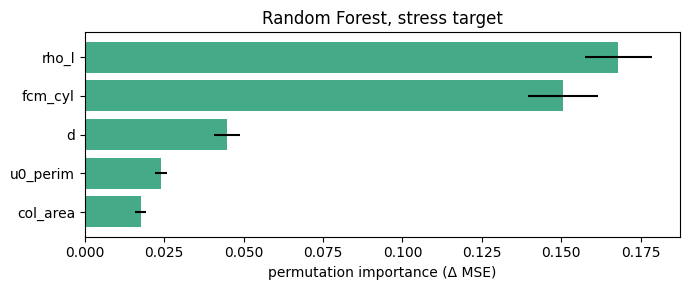

In [3]:
imp = pd.read_csv(RESULTS/'feature_importance.csv')
display(imp.round(4))
plt.figure(figsize=(7,3)); plt.barh(imp.feature, imp.importance, xerr=imp['std'], color='#4a8')
plt.gca().invert_yaxis(); plt.xlabel('permutation importance (Δ MSE)'); plt.title('Random Forest, stress target'); plt.tight_layout(); plt.show()

**Takeaway.** On the stress target the dominant features are **`rho_l`** (reinforcement ratio) and **`fcm_cyl`** (concrete strength) — the actual mechanical drivers — while `d` is minor. The original *“`d` dominates”* conclusion was a load/size-effect artifact. However, the column-geometry features (`col_area`) remain negligible, so the original conclusion that **column profile can be dropped** does survive the correction.